# Delivery Time EDA
Exploratory analysis of `data/raw/orders.csv` for the QuickCart delivery prediction platform.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

# Handles both execution contexts: interactive (cwd = notebooks/) and
# command-line nbconvert (cwd can default to the repo root instead).
candidate_paths = ["data/raw/orders.csv", "../data/raw/orders.csv"]
data_path = next(p for p in candidate_paths if os.path.exists(p))

df = pd.read_csv(
    data_path,
    dtype={"origin_zip": str, "destination_zip": str},
    parse_dates=["order_timestamp"],
)
print(f"Loaded from: {data_path}")
df.shape

Loaded from: ../data/raw/orders.csv


(100000, 13)

## Missing Values

In [2]:
df.isnull().sum()

order_id                         0
order_timestamp                  0
origin_zip                       0
destination_zip                  0
carrier_code                     0
item_category                    0
distance_miles                   0
warehouse_processing_hours       0
weather_score                    0
holiday_flag                     0
weekend_flag                     0
historical_carrier_delay_days    0
actual_delivery_days             0
dtype: int64

## Cardinality of Categorical Fields

In [3]:
for col in ["carrier_code", "item_category", "origin_zip", "destination_zip"]:
    print(col, "->", df[col].nunique(), "unique values")

carrier_code -> 5 unique values
item_category -> 4 unique values
origin_zip -> 63227 unique values
destination_zip -> 63322 unique values


## Target Distribution

In [4]:
df["actual_delivery_days"].describe()

count    100000.000000
mean          5.953362
std           2.152023
min           0.500000
25%           4.380000
50%           5.950000
75%           7.540000
max          13.630000
Name: actual_delivery_days, dtype: float64

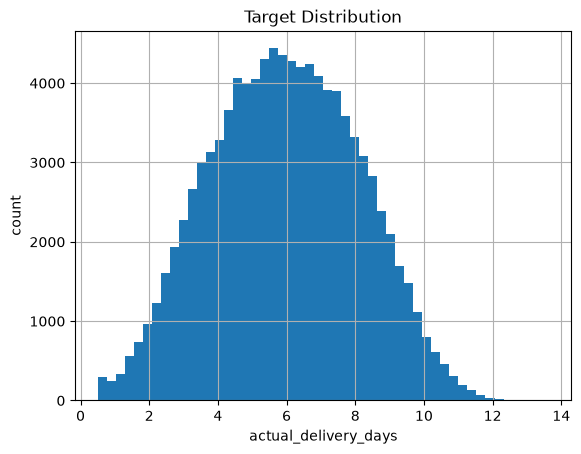

In [5]:
df["actual_delivery_days"].hist(bins=50)
plt.xlabel("actual_delivery_days")
plt.ylabel("count")
plt.title("Target Distribution")
plt.show()

## Delivery Days by Carrier

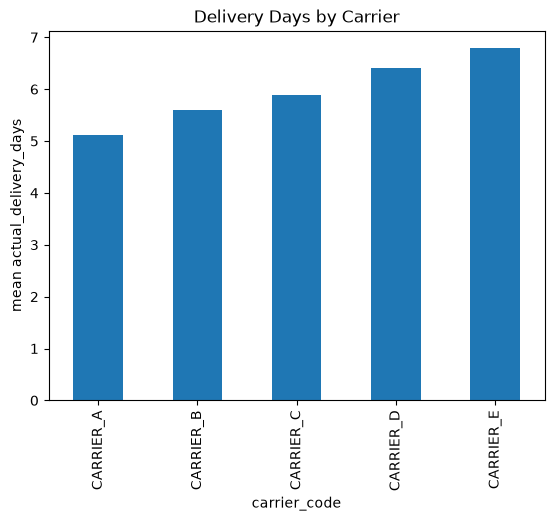

In [6]:
df.groupby("carrier_code")["actual_delivery_days"].mean().sort_values().plot(kind="bar")
plt.ylabel("mean actual_delivery_days")
plt.title("Delivery Days by Carrier")
plt.show()

## Delivery Days by Item Category

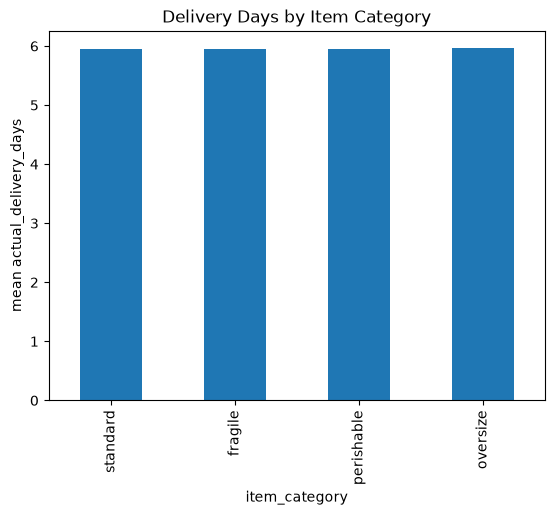

In [7]:
df.groupby("item_category")["actual_delivery_days"].mean().sort_values().plot(kind="bar")
plt.ylabel("mean actual_delivery_days")
plt.title("Delivery Days by Item Category")
plt.show()

## Distance vs Target

                      distance_miles  actual_delivery_days
distance_miles              1.000000              0.803231
actual_delivery_days        0.803231              1.000000


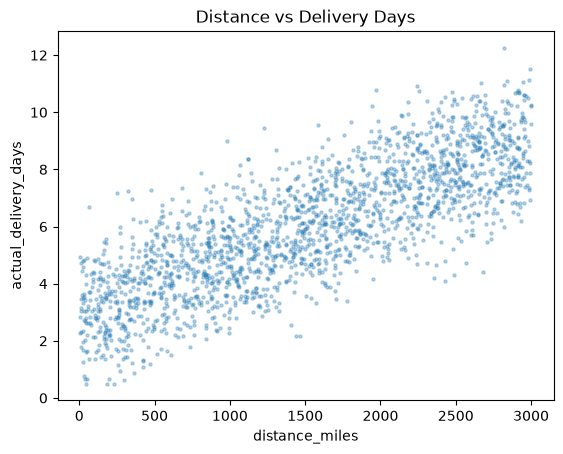

In [8]:
print(df[["distance_miles", "actual_delivery_days"]].corr())
sample_idx = df["distance_miles"].sample(2000, random_state=42).index
plt.scatter(df.loc[sample_idx, "distance_miles"], df.loc[sample_idx, "actual_delivery_days"], alpha=0.3, s=5)
plt.xlabel("distance_miles")
plt.ylabel("actual_delivery_days")
plt.title("Distance vs Delivery Days")
plt.show()

## Weather Impact

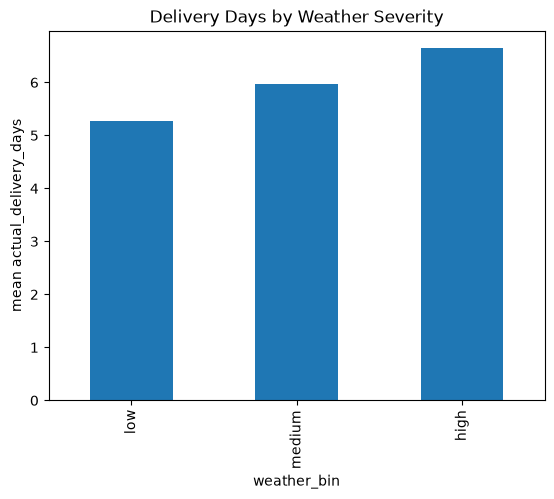

In [9]:
df["weather_bin"] = pd.cut(df["weather_score"], bins=[0, 3, 7, 10], labels=["low", "medium", "high"])
df.groupby("weather_bin", observed=True)["actual_delivery_days"].mean().plot(kind="bar")
plt.ylabel("mean actual_delivery_days")
plt.title("Delivery Days by Weather Severity")
plt.show()

## Holiday Impact

In [10]:
df.groupby("holiday_flag")["actual_delivery_days"].mean()

holiday_flag
0    5.872469
1    6.890116
Name: actual_delivery_days, dtype: float64

## Warehouse Processing Impact

In [11]:
df[["warehouse_processing_hours", "actual_delivery_days"]].corr()

,warehouse_processing_hours,actual_delivery_days
warehouse_processing_hours,1.00000,0.39701
actual_delivery_days,0.39701,1.00000


## Outlier Ranges (IQR method)

In [12]:
for col in ["distance_miles", "warehouse_processing_hours", "actual_delivery_days"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR bounds=[{lower:.2f}, {upper:.2f}]  outliers={n_outliers}")

distance_miles: IQR bounds=[-1499.76, 4497.14]  outliers=0
warehouse_processing_hours: IQR bounds=[-34.30, 107.30]  outliers=0
actual_delivery_days: IQR bounds=[-0.36, 12.28]  outliers=16


## Summary\n\nSee `reports/eda_summary.md` for the written findings, including target leakage notes.